# 05 - Validación

Cargué el modelo ya entrenado y lo miré en detalle: confusion matrix, ROC, feature importance. También comparé correlación lineal vs importancia del modelo.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    f1_score, roc_auc_score, roc_curve)

sns.set_theme(style='whitegrid')
RAW = Path('..') / 'data' / 'raw'
MODELS = Path('..') / 'models'

df = pd.read_excel(RAW / 'smoking_labeled.xlsx')
model = joblib.load(MODELS / 'model.joblib')
model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](24,)","['gender','age','height(cm)',...,'Gtp','dental caries','tartar']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,24
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns

In [2]:
TARGET = 'smoking'
DROP_COLS = ['ID', 'oral']
X = df.drop(columns=[TARGET] + DROP_COLS)
y = df[TARGET]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
print('Test:', X_test.shape)

Test: (10000, 24)


## Metricas principales

In [3]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]
print('F1 target=1 :', round(f1_score(y_test, y_pred, pos_label=1), 4))
print('ROC AUC     :', round(roc_auc_score(y_test, y_proba), 4))
print()
print(classification_report(y_test, y_pred, digits=4))

F1 target=1 : 0.7037
ROC AUC     : 0.8593

              precision    recall  f1-score   support

           0     0.8351    0.8058    0.8202      6334
           1     0.6836    0.7250    0.7037      3666

    accuracy                         0.7762     10000
   macro avg     0.7594    0.7654    0.7620     10000
weighted avg     0.7796    0.7762    0.7775     10000



## Matriz de confusion

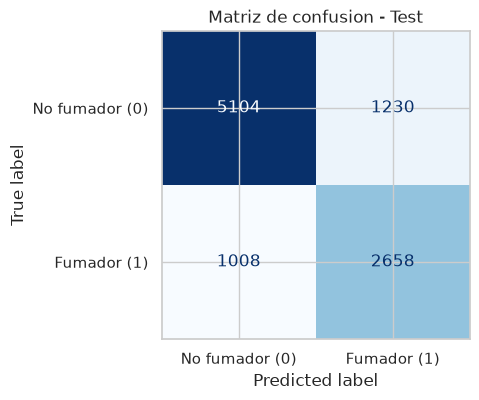

In [4]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(4.5, 4))
ConfusionMatrixDisplay(cm, display_labels=['No fumador (0)', 'Fumador (1)']).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Matriz de confusion - Test')
plt.show()

## Curva ROC

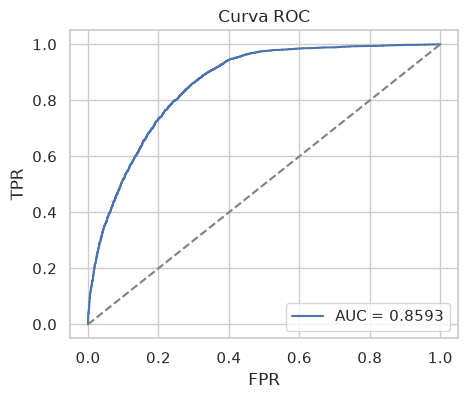

In [5]:
fpr, tpr, thr = roc_curve(y_test, y_proba)
fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_test, y_proba):.4f}')
ax.plot([0,1], [0,1], '--', color='gray')
ax.set_xlabel('FPR'); ax.set_ylabel('TPR'); ax.set_title('Curva ROC')
ax.legend(); plt.show()

## Feature importance del modelo

Sacada del booster de XGBoost (gain). La esperamos: `gender_M` (o `gender`) entre las top, y variables clinicas (`hemoglobin`, `Gtp`, `triglyceride`, `height(cm)`) tambien arriba.

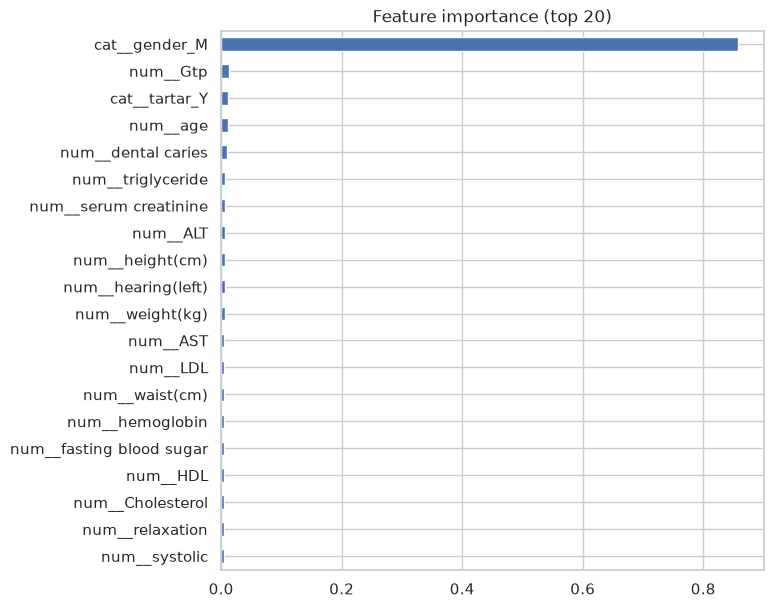

cat__gender_M            0.857406
num__Gtp                 0.012926
cat__tartar_Y            0.011268
num__age                 0.011118
num__dental caries       0.009200
num__triglyceride        0.006915
num__serum creatinine    0.006428
num__ALT                 0.006102
num__height(cm)          0.005676
num__hearing(left)       0.005618
num__weight(kg)          0.005567
num__AST                 0.005369
num__LDL                 0.005317
num__waist(cm)           0.005225
num__hemoglobin          0.005037
dtype: float32

In [6]:
# XGBoost usa gain por defecto
prep = model.named_steps['prep']
clf  = model.named_steps['clf']
feat_names = prep.get_feature_names_out()
imp = pd.Series(clf.feature_importances_, index=feat_names).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 7))
imp.head(20).sort_values().plot(kind='barh', ax=ax)
ax.set_title('Feature importance (top 20)')
plt.show()
imp.head(15)

## Importancia del modelo vs correlacion lineal con el target

La correlacion lineal subestima a `gender` (categorica) y a la mayoria de las features categoricas en general.

In [7]:
num_cols = df.select_dtypes(include='number').columns.drop(['ID', TARGET])
corr_abs = df[num_cols.tolist() + [TARGET]].corr()[TARGET].drop(TARGET).abs().sort_values(ascending=False)

top_corr = set(corr_abs.head(10).index.tolist())
top_imp  = {n.split('__')[-1] for n in imp.head(10).index.tolist()}
print('Top 10 por correlacion lineal :', sorted(top_corr))
print('Top 10 por feature importance :', sorted(top_imp))
print()
print('Comunes:', sorted(top_corr & top_imp))
print('Solo en correlacion:', sorted(top_corr - top_imp))
print('Solo en importance :', sorted(top_imp - top_corr))

Top 10 por correlacion lineal : ['Gtp', 'HDL', 'age', 'height(cm)', 'hemoglobin', 'relaxation', 'serum creatinine', 'triglyceride', 'waist(cm)', 'weight(kg)']
Top 10 por feature importance : ['ALT', 'Gtp', 'age', 'dental caries', 'gender_M', 'hearing(left)', 'height(cm)', 'serum creatinine', 'tartar_Y', 'triglyceride']

Comunes: ['Gtp', 'age', 'height(cm)', 'serum creatinine', 'triglyceride']
Solo en correlacion: ['HDL', 'hemoglobin', 'relaxation', 'waist(cm)', 'weight(kg)']
Solo en importance : ['ALT', 'dental caries', 'gender_M', 'hearing(left)', 'tartar_Y']
